In [1]:
import pandas as pd
import numpy as np
import re

In [2]:

data = pd.read_csv("liverpool_2223_season.csv")

<Axes: xlabel='Day'>

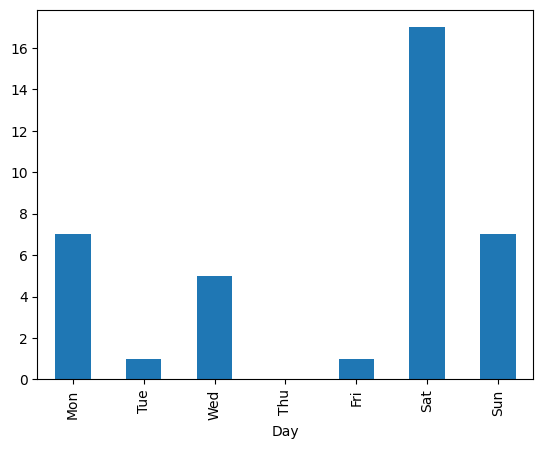

In [3]:
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
day_counts = data.Day.value_counts() # get count for each day
day_counts["Thu"] = 0
day_counts[day_order].plot(kind="bar") #set the order based on day_order

In [4]:
data['result'] = np.where(data['GF'] > data['GA'], 'W', np.where(data['GF'] == data['GA'], "D", "L"))
data['pts'] = np.where(data['GF'] > data['GA'], 3, np.where(data['GF'] == data['GA'], 1, 0))
print(data)

          Date  Day Venue  GF  GA         Opponent result  pts
0   2022-08-06  Sat  Away   2   2           Fulham      D    1
1   2022-08-15  Mon  Home   1   1   Crystal Palace      D    1
2   2022-08-22  Mon  Away   1   2   Manchester Utd      L    0
3   2022-08-27  Sat  Home   9   0      Bournemouth      W    3
4   2022-08-31  Wed  Home   2   1    Newcastle Utd      W    3
5   2022-09-03  Sat  Away   0   0          Everton      D    1
6   2022-10-01  Sat  Home   3   3         Brighton      D    1
7   2022-10-09  Sun  Away   2   3          Arsenal      L    0
8   2022-10-16  Sun  Home   1   0  Manchester City      W    3
9   2022-10-19  Wed  Home   1   0         West Ham      W    3
10  2022-10-22  Sat  Away   0   1  Nott'ham Forest      L    0
11  2022-10-29  Sat  Home   1   2     Leeds United      L    0
12  2022-11-06  Sun  Away   2   1        Tottenham      W    3
13  2022-11-12  Sat  Home   3   1      Southampton      W    3
14  2022-12-26  Mon  Away   3   1      Aston Villa     

In [5]:
def check(value):
    if value["GF"] > value["GA"]:
        return "W"
    elif value["GF"] == value["GA"]:
        return "D"
    return "L"

data["result"] = data.apply(check,1)


pts_dic = {'W': 3, 'D': 1, 'L': 0}
data["pts"] = data["result"].map(pts_dic)
print(data)

          Date  Day Venue  GF  GA         Opponent result  pts
0   2022-08-06  Sat  Away   2   2           Fulham      D    1
1   2022-08-15  Mon  Home   1   1   Crystal Palace      D    1
2   2022-08-22  Mon  Away   1   2   Manchester Utd      L    0
3   2022-08-27  Sat  Home   9   0      Bournemouth      W    3
4   2022-08-31  Wed  Home   2   1    Newcastle Utd      W    3
5   2022-09-03  Sat  Away   0   0          Everton      D    1
6   2022-10-01  Sat  Home   3   3         Brighton      D    1
7   2022-10-09  Sun  Away   2   3          Arsenal      L    0
8   2022-10-16  Sun  Home   1   0  Manchester City      W    3
9   2022-10-19  Wed  Home   1   0         West Ham      W    3
10  2022-10-22  Sat  Away   0   1  Nott'ham Forest      L    0
11  2022-10-29  Sat  Home   1   2     Leeds United      L    0
12  2022-11-06  Sun  Away   2   1        Tottenham      W    3
13  2022-11-12  Sat  Home   3   1      Southampton      W    3
14  2022-12-26  Mon  Away   3   1      Aston Villa     

In [6]:
for x in set(data["Opponent"]):
    print(f"Points against {x}: {sum(data[data["Opponent"] == x]["pts"])}")


for x, y in data.iloc[0:].groupby("Opponent"):
    print(x)
    print(y)

Points against Newcastle Utd: 6
Points against Brighton: 1
Points against Bournemouth: 3
Points against West Ham: 6
Points against Manchester Utd: 3
Points against Nott'ham Forest: 3
Points against Brentford: 3
Points against Crystal Palace: 2
Points against Arsenal: 1
Points against Fulham: 4
Points against Leeds United: 3
Points against Manchester City: 3
Points against Southampton: 4
Points against Leicester City: 6
Points against Everton: 4
Points against Tottenham: 6
Points against Chelsea: 2
Points against Wolves: 3
Points against Aston Villa: 4
Arsenal
          Date  Day Venue  GF  GA Opponent result  pts
7   2022-10-09  Sun  Away   2   3  Arsenal      L    0
28  2023-04-09  Sun  Home   2   2  Arsenal      D    1
Aston Villa
          Date  Day Venue  GF  GA     Opponent result  pts
14  2022-12-26  Mon  Away   3   1  Aston Villa      W    3
36  2023-05-20  Sat  Home   1   1  Aston Villa      D    1
Bournemouth
          Date  Day Venue  GF  GA     Opponent result  pts
3   2022-

In [7]:
data["total_pts"] = data['pts'].cumsum()
print(data["total_pts"].iloc[len(data) - 1])

67


In [ ]:
import pdb
def fn1(str1):
    pdb.set_trace()
    out_string = re.split('[LD]+', str1)
    st1 = [len(x) for x in out_string]
    return st1


win = data["result"].str.cat()
rle_out = fn1(win)
print(np.max(rle_out))

['DD', 'WWDD', 'WW', 'WWWW', 'D', 'WWDWW', 'DDWWWWWWWDD']
[2, 4, 2, 4, 1, 5, 11]
11
